# Patch-Based Unsupervised Anomaly Detection and Localization via CNN Feature Extraction

### Dataset & Experimental Setup

The Benchmark: MVTec AD Dataset (Capsule Category)

A high-resolution industrial dataset specifically designed to evaluate unsupervised anomaly localization.

The Training Constraint (One-Class Learning): 
The memory bank was built using 100% nominal (defect-free) training images. The model was never exposed to anomalous data during profiling.

The Evaluation Set: The test set introduces complex, multi-class defects (e.g., cracks, pokes, squeezes, and scratches).

The Systems Challenge:

Defects are microscopic, often occupying less than 1% of the total pixel space, requiring extreme spatial sensitivity from the feature extractor.

In [27]:
# Import necessary libraries
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc

## STEP 1: CONFIGURATION & DATA LOADING

In [7]:
# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [10]:
# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
# Only use capsule data for the demo 
# Locate the folder
SCRIPT_DIR = os.getcwd()
TRAIN_PATH = os.path.join(SCRIPT_DIR, 'capsule', 'train')
TEST_PATH = os.path.join(SCRIPT_DIR, 'capsule', 'test')

if not os.path.exists(TRAIN_PATH):
    print("WARNING: The 'capsule/train' folder was not found in the current directory.")

In [15]:
# Load datasets
train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform)
test_dataset = ImageFolder(root=TEST_PATH, transform=transform)

In [16]:
# Map 'good' to 0 (Normal) and all other folders to 1 (Anomaly)
good_class_index = test_dataset.class_to_idx['good']
test_dataset.samples = [(path, 0 if target == good_class_index else 1) for path, target in test_dataset.samples]
test_dataset.imgs = test_dataset.samples
test_dataset.targets = [target for _, target in test_dataset.samples]

In [17]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Loaded {len(train_dataset)} normal training images.")
print(f"Loaded {len(test_dataset)} mixed testing images.")

Loaded 219 normal training images.
Loaded 132 mixed testing images.


## STEP 2: MODEL ARCHITECTURE

In [22]:
class UnsupervisedFeatureExtractor(nn.Module):
    """
    Feature Extraction Pipeline:
    Acts as the mathematical translator for the anomaly detection system.
    Bypasses standard classification outputs to construct a dense spatial memory bank.
    """
    def __init__(self):
        super().__init__()

        # Load pre-trained ResNet-18 model, to provide a universal visual vocabulary
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Stage 1: Extracts low-level structural features 
        self.stage1 = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2
        )
        # Stage 2: Extracts mid-to-high-level semantic features 
        self.stage2 = resnet.layer3

        # Freeze the weights. We utilize the model strictly as a frozen forward-pass feature extractor
        # Dramatically reducing memory overhead.
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        # Generate local feature maps
        feat_l2 = self.stage1(x)  # 28x28 grid, 128 channels
        feat_l3 = self.stage2(feat_l2)  # 14x14 grid, 256 channels

        # Resize layer2 feature map to 14x14 to align with layer3, allowing for overlay the local and global features without data distortion.
        feat_l2_resized = nn.functional.interpolate(feat_l2, size=(14, 14), mode='bilinear', align_corners=False)

       # Stack the local and global features together along the channel dimension.
        concat_features = torch.cat([feat_l2_resized, feat_l3], dim=1)  # 14x14 grid, 384 channels
        return concat_features


In [23]:
# Instantiate the pipeline
model = UnsupervisedFeatureExtractor().to(device).eval()

## STEP 3: STATISTICAL PROFILING

In [25]:
def build_normal_profile(loader, extractor):
    """
    Memory Bank Construction:
    Processes the entirely nominal (defect-free) training set to build 
    a dense, high-dimensional representation of 'normality'.
    """

    print("\nBuilding Normal Profile from training data...")
    all_patches = []
    
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            # Feature Extraction: Pass batch through the frozen CNN.
            spatial_features = extractor(images) # Shape: [Batch, 384 channels, 14 H, 14 W]
            B, C, H, W = spatial_features.shape
            # Tensor Transformation (Flattening the Spatial Grid)
            patches = spatial_features.permute(0, 2, 3, 1).reshape(-1, C)
            all_patches.append(patches)

    # Memory Bank Aggregation: Concatenate all isolated patches into a single, massive feature bank       
    train_patch_bank = torch.cat(all_patches, dim=0) # Shape: [Total Normal Patches, 384]

    # Calculate the ultimate mean vector to represent the idealized 'perfect' patch
    mean_vector = torch.mean(train_patch_bank, dim=0).cpu().numpy()
    print(f"Normal Profile (Patch Memory Bank) built successfully with shape {train_patch_bank.shape}.")
    return mean_vector, train_patch_bank

## STEP 4: EVALUATION & VISUALIZATION

In [ ]:
def evaluate_and_explain(image_tensor, original_image_path, extractor, mean_vec, feature_bank, threshold):
    """
    Inference & Native Explainability Pipeline:
    Scores a new image for anomalies and maps the distance scores 
    into a high-resolution XAI heatmap directly in the notebook.
    """
    image_tensor = image_tensor.to(device)
    
    with torch.no_grad():
        # Feature Extraction & Flattening
        spatial_features = extractor(image_tensor) 
        B, C, H, W = spatial_features.shape
        test_patches = spatial_features.permute(0, 2, 3, 1).reshape(-1, C) 
        
        # Distance Computation (1-Nearest Neighbor)
        dists = torch.cdist(test_patches, feature_bank) 
        patch_scores = dists.min(dim=1).values 
        patch_scores_np = patch_scores.cpu().numpy()
        
    # Global anomaly score
    anomaly_score = float(np.max(patch_scores_np))
    is_anomaly = anomaly_score > threshold
    
    # Spatial Reassembly & Heatmap Generation
    heatmap = patch_scores_np.reshape(H, W)
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8) 
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Visual Overlay
    img = cv2.imread(original_image_path)
    img = cv2.resize(img, (224, 224))
    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Input Image
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Input Image")
    axes[0].axis('off')
    
    # Heatmap Overlay
    status = "ANOMALY DETECTED" if is_anomaly else "NORMAL"
    # Use a red title for anomalies to make it pop during the presentation
    title_color = 'red' if is_anomaly else 'green' 
    
    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"{status}\nScore: {anomaly_score:.2f} | Threshold: {threshold:.2f}", color=title_color, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    
    # # Save to disk
    # if save_path:
    #     plt.savefig(save_path)
    #     print(f"Saved visualization to: {save_path}")
        
    # # MANDATORY: Display directly in the Jupyter Notebook cell output
    plt.show()

## STEP 5: EXECUTION

In [ ]:
mean_normal_vector, normal_feature_bank = build_normal_profile(train_loader, model)

# 2. Evaluate the test set to find the optimal threshold
print("\nEvaluating test set to calculate ROC-AUC...")
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        spatial_features = model(images) # [1, 384, 14, 14]
        B, C, H, W = spatial_features.shape
        test_patches = spatial_features.permute(0, 2, 3, 1).reshape(-1, C) # [196, 384]
        
        # Compute Euclidean distances from test patches to normal feature bank
        dists = torch.cdist(test_patches, normal_feature_bank) # [196, N * 196]
        patch_scores = dists.min(dim=1).values # [196]
        image_score = float(patch_scores.max().cpu().numpy())
        
        y_scores.append(image_score)
        y_true.append(labels.item())

# Calculate metrics
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Model ROC-AUC: {roc_auc:.4f}")
print(f"Optimal Distance Threshold calculated at: {optimal_threshold:.4f}\n")


Building Normal Profile from training data...
Normal Profile (Patch Memory Bank) built successfully with shape torch.Size([42924, 384]).

Evaluating test set to calculate ROC-AUC...
Model ROC-AUC: 0.9350
Optimal Distance Threshold calculated at: 1.8815



In [ ]:
# Find one normal image and one anomaly image from the test set for the demo
normal_idx, anomaly_idx = None, None
for i, target in enumerate(test_dataset.targets):
    if target == 0 and normal_idx is None:
        normal_idx = i
    if target == 1 and anomaly_idx is None:
        anomaly_idx = i
    if normal_idx is not None and anomaly_idx is not None:
        break

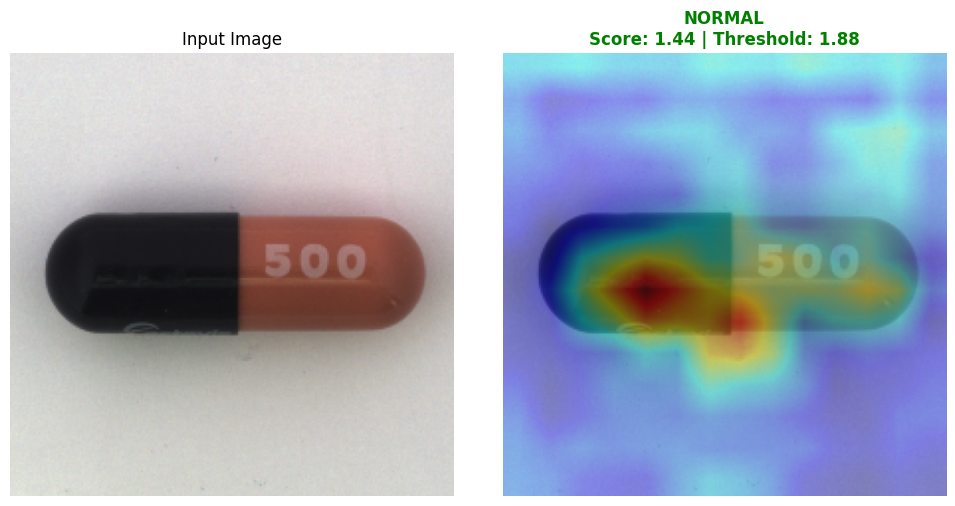

In [ ]:
# Show Normal Example
normal_img_tensor, _ = test_dataset[normal_idx]
normal_img_path, _ = test_dataset.samples[normal_idx]
evaluate_and_explain(normal_img_tensor.unsqueeze(0), normal_img_path, model, mean_normal_vector, normal_feature_bank, optimal_threshold)


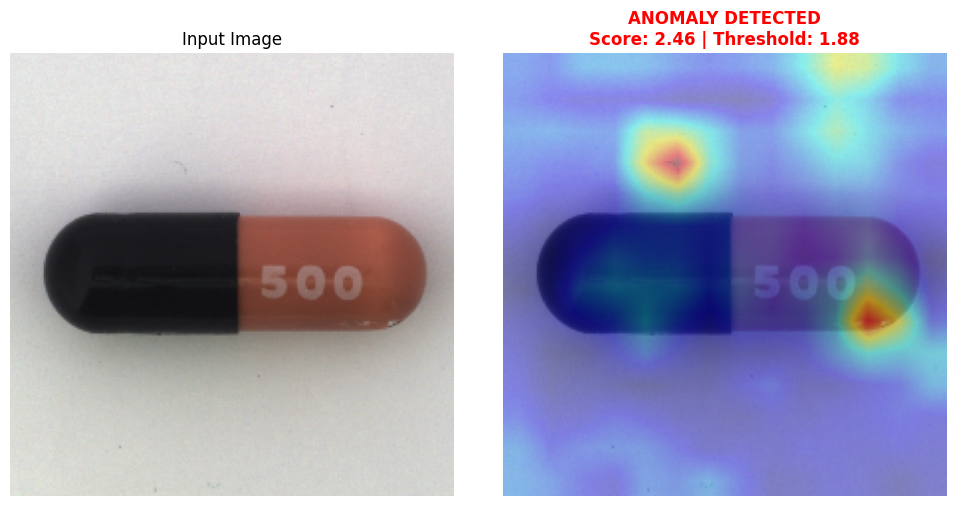

In [ ]:
# Show Anomaly Example
anomaly_img_tensor, _ = test_dataset[anomaly_idx]
anomaly_img_path, _ = test_dataset.samples[anomaly_idx]
evaluate_and_explain(anomaly_img_tensor.unsqueeze(0), anomaly_img_path, model, mean_normal_vector, normal_feature_bank, optimal_threshold)